<a href="https://colab.research.google.com/github/ian-menachery/ECON3916-Statistical-Machine-Learning/blob/main/%5BProject_1%5D_Phase_4_Final_Report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col


df = pd.read_csv('ResumeNames.csv')
df['call'] = np.where(df['call'] == 'yes', 1, 0)

# Baseline
mod_baseline = smf.ols('call ~ C(ethnicity)', data=df).fit(cov_type='HC1')

# Adding Resume Quality Control
mod_quality = smf.ols('call ~ C(ethnicity) + C(quality)', data=df).fit(cov_type='HC1')

# The Approved Phase 3 Full Multivariate Model
formula_full = 'call ~ C(ethnicity) + C(quality) + experience + C(city)'
mod_full = smf.ols(formula=formula_full, data=df).fit(cov_type='HC1')

# Generate Professional Regression Table
table_2 = summary_col(
    [mod_baseline, mod_quality, mod_full],
    stars=True,
    model_names=['(1) Baseline', '(2) Quality Control', '(3) Full Model'],
    info_dict={'N':lambda x: f"{int(x.nobs)}", 'R2':lambda x: f"{x.rsquared:.3f}"}
)
print("--- TABLE 2: Causal Effect of Perceived Race on Callback Probability ---")
print(table_2)

--- TABLE 2: Causal Effect of Perceived Race on Callback Probability ---

                     (1) Baseline (2) Quality Control (3) Full Model
--------------------------------------------------------------------
Intercept            0.0645***    0.0715***           0.0624***     
                     (0.0050)     (0.0064)            (0.0107)      
C(ethnicity)[T.cauc] 0.0320***    0.0320***           0.0320***     
                     (0.0078)     (0.0078)            (0.0078)      
C(quality)[T.low]                 -0.0141*            -0.0117       
                                  (0.0078)            (0.0077)      
C(city)[T.chicago]                                    -0.0245***    
                                                      (0.0080)      
experience                                            0.0028***     
                                                      (0.0009)      
R-squared            0.0035       0.0041              0.0096        
R-squared Adj.       0.0033  

In [3]:
# Table Summary Stats comparing Treated (afam) vs Control (cauc)
table_1 = df.groupby('ethnicity')[['call', 'experience', 'jobs']].agg(['mean', 'std']).round(3).T
print("--- TABLE 1: Summary Statistics by Treatment Group ---")
print(table_1)

--- TABLE 1: Summary Statistics by Treatment Group ---
ethnicity         afam   cauc
call       mean  0.064  0.097
           std   0.246  0.295
experience mean  7.830  7.856
           std   5.011  5.079
jobs       mean  3.658  3.664
           std   1.219  1.219


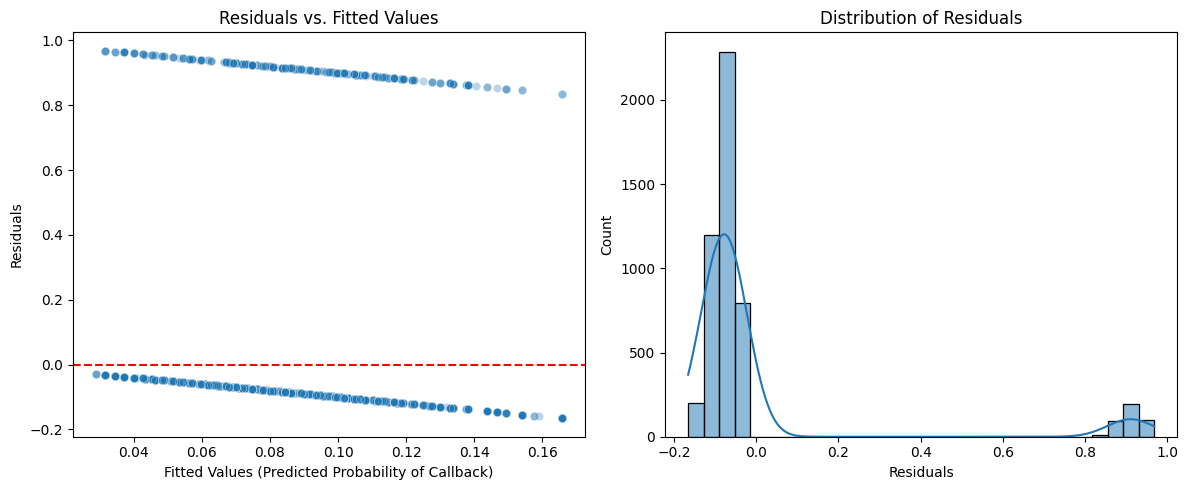

In [4]:
#  Residuals vs. Fitted Values (Checking for heteroscedasticity)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=mod_full.fittedvalues, y=mod_full.resid, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs. Fitted Values")
plt.xlabel("Fitted Values (Predicted Probability of Callback)")
plt.ylabel("Residuals")

#  Distribution of Errors
plt.subplot(1, 2, 2)
sns.histplot(mod_full.resid, bins=30, kde=True)
plt.title("Distribution of Residuals")
plt.xlabel("Residuals")

plt.tight_layout()
plt.show()